## 14 PCA
### Principal Component Analysis (PCA)
By **Mohan Sirumalla**
***

**Principal Component Analysis (PCA)** is an unsupervised machine learning technique used to reduce data dimensionality while retaining maximum variance (information).\
It transforms high-dimensional, correlated features into a smaller set of uncorrelated "principal components".\
PCA aids in data visualization, speeding up algorithms, and noise reduction.

### Task 1: Exploratory Data Analysis (EDA):

#### 1. Load the dataset and perform basic data exploration.

In [1]:
import os
# 1. Set environment variable BEFORE importing sklearn to suppress warning
os.environ["OMP_NUM_THREADS"] = "1"
import warnings
import pandas as pd
warnings.filterwarnings('ignore', category=FutureWarning)

# import libraries
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


print('Loaded the basic libraries')

Loaded the basic libraries


In [2]:
# Fro formated output
# Define ANSI codes for clarity
BOLD = '\033[1m'
END = '\033[0m' # Resets the format

In [3]:
df= pd.read_csv('14_wine.csv')
df.head() # display 1st 5  observations

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.shape

(178, 14)

We haev 178 data entries and 14 columns. Here the type column will need to be dropped. But we will keep it to perform our basic EDA.

In [5]:

df.info() # prints a concise summary of a DataFrame, including index and column data types, non-null values, and memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [6]:
df['Type']= df['Type'].astype('object')

In [7]:

df.describe() #generates descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution.

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [8]:
df.columns # to displas only columns

Index(['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')

In [9]:
# Check Duplicate Records if any
if not df.duplicated().any():
    print("No Duplicates")
else:
    print(f"Duplicate records : {len(df[df.duplicated(keep=False)])}") 
    # print(df[df.duplicated(keep=False)])


No Duplicates


In [10]:
# Check Null values
if df.isnull().any().any():
    print("Columns with null values and their counts:")
    # The original logic, slightly refined for clarity
    null_counts = df.loc[:, df.isnull().any()].isnull().sum()
    print(null_counts)
else:
    print("No null values found in the DataFrame.")

No null values found in the DataFrame.


In [11]:
# Select  numeric columns and non numeric columns
numeric_cols_df = df.select_dtypes(include='number')
print('Numberic',numeric_cols_df.columns)
non_numeric_cols_df = df.select_dtypes(exclude='number')
print('Non-Numberic',non_numeric_cols_df.columns)

Numberic Index(['Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')
Non-Numberic Index(['Type'], dtype='object')


#### 2. Examine the distribution of features using histograms, box plots, or density plots.

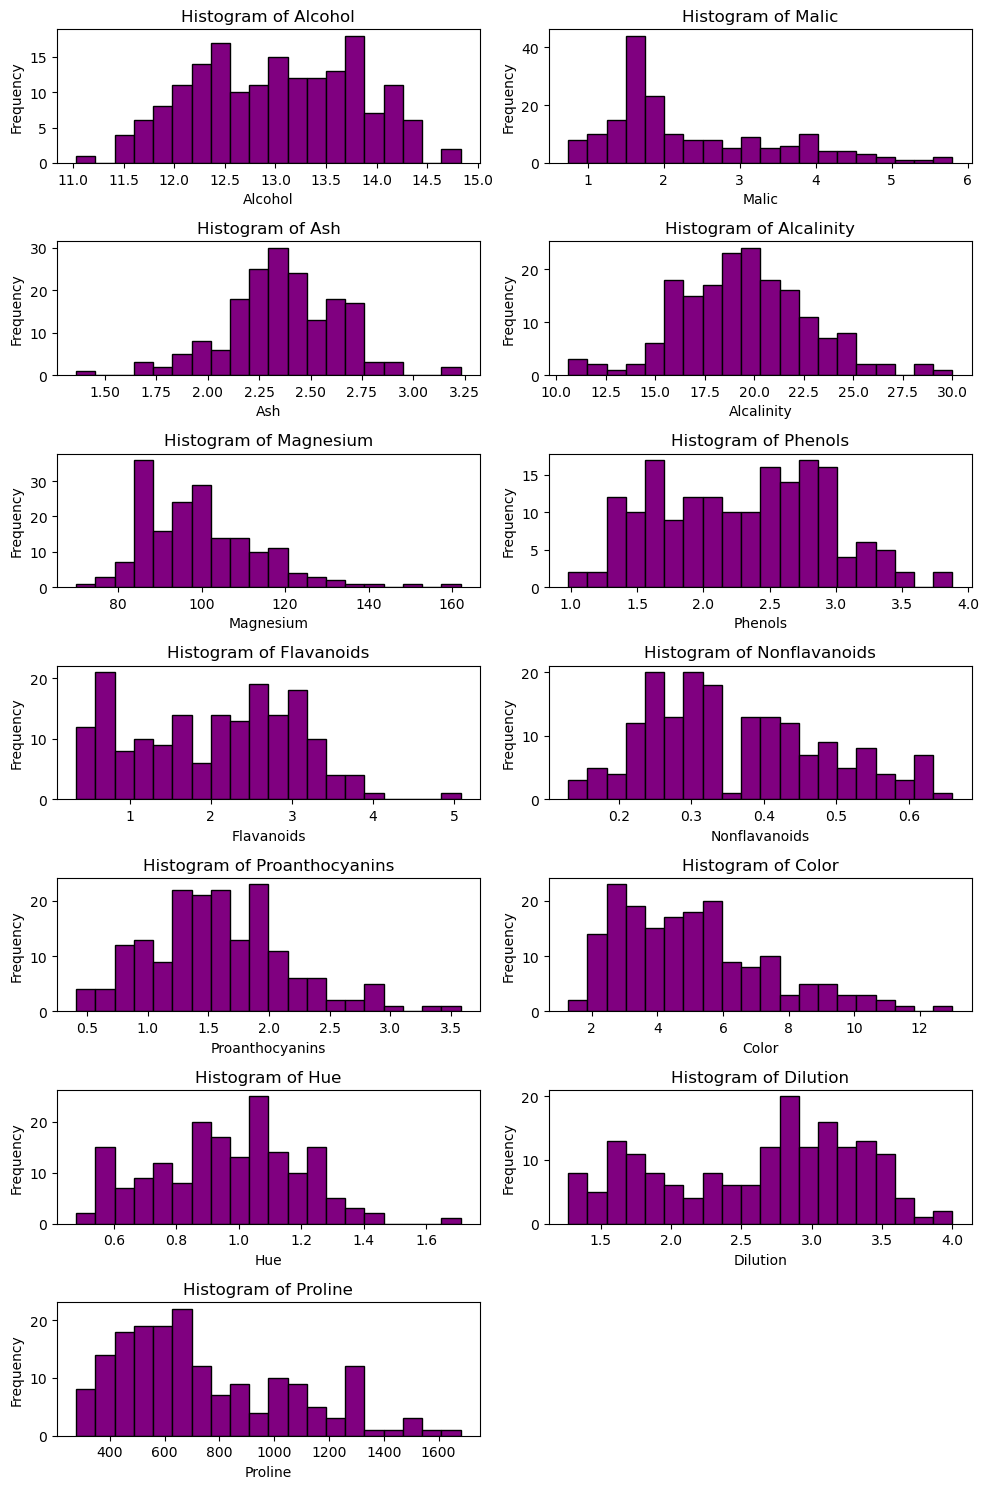

In [12]:
# Create a figure and axis array with subplots
fig, axes = plt.subplots(7, 2, figsize=(10, 15))

# Flatten the 2D axis array to make it easier to iterate
axes = axes.flatten()

# Loop through each numeric column and plot its histogram
for i, col in enumerate(numeric_cols_df.columns):
    axes[i].hist(numeric_cols_df[col], bins=20, color='purple', edgecolor='black')
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# 4. Identify and remove unused subplots
for ax in axes:
    # Check if the axis is empty (no artists/children)
    if not ax.has_data(): # A simpler check for general use
    # Alternatively, check len(ax.get_children()) == 0, though not always perfect if text or other elements are present by default.
        fig.delaxes(ax) # Remove the axis from the figure


# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [13]:
df.columns

Index(['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')

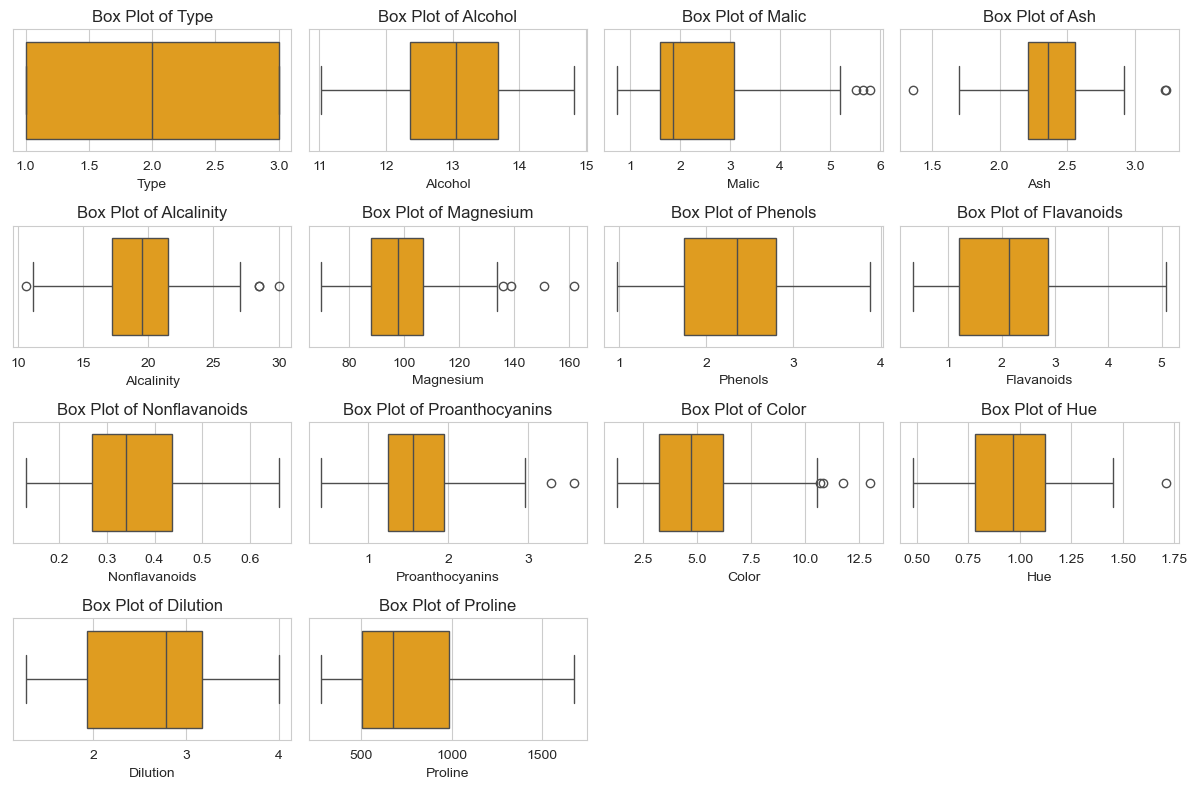

In [14]:
plt.figure(figsize=(12,8))
sns.set_style(style='whitegrid')
for index,col in enumerate(df.columns):
    plt.subplot(4,4,index+1)
    sns.boxplot(x=col,data=df,color= 'orange')
    plt.title(f'Box Plot of {col}')
plt.tight_layout()    
plt.show()


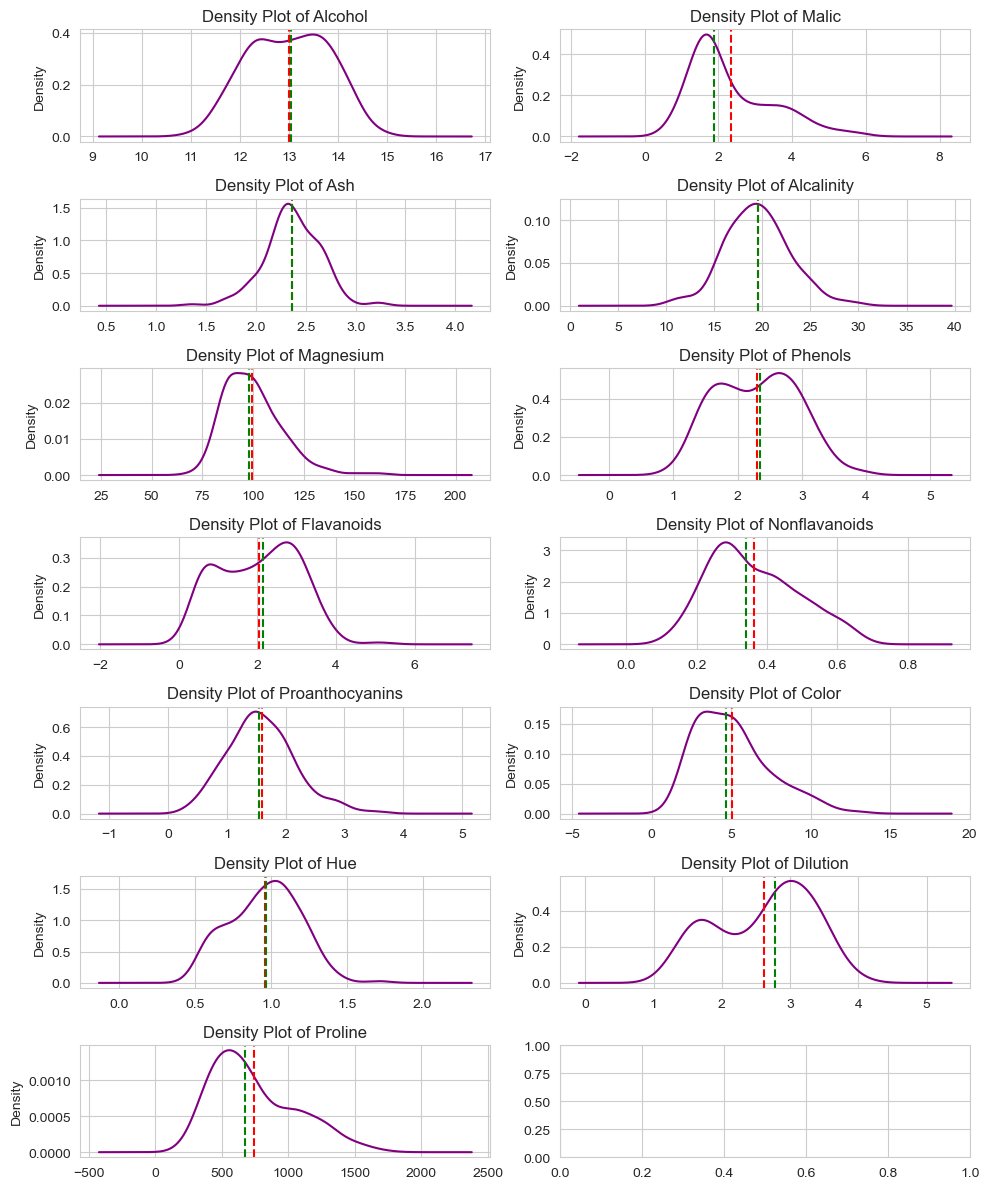

In [15]:
#Density Plots

# Create a figure and axis array with subplots
fig, axes = plt.subplots(7, 2, figsize=(10, 12))

# Flatten the 2D axis array to make it easier to iterate
axes = axes.flatten()

# Loop through each numeric column and plot its histogram
for i, column in enumerate(numeric_cols_df.columns):
    ax = numeric_cols_df[column].plot.density(ax = axes[i], color='purple')
    ax.axvline(numeric_cols_df[column].mean(), color = 'red', linestyle ='--')
    ax.axvline(numeric_cols_df[column].median(), color = 'green', linestyle ='--')
    ax.set_title(f'Density Plot of {column}')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [16]:
df.columns

Index(['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')

**Insights:**

**Alcohol:**\
The distribution of Alcohol appears to be approximately normal, with a slight left skew.\
The histogram shows a concentration around the mean value of 13, with fewer extreme values at the tails. This also exihibits bi-modal nataure with peaks at 12 and 14.\
This suggests potential subgroups or clusters within the data.

**Malic:**\
The distribution is distinctly right-skewed with a single mode\
But there is a slight peak on the right-tail

**Ash:**\
Ash almost has a normal distribution with a very slight positive skewness (mean>median).\
The spread is small, as indicated by the low standard deviation (0.27)

**Alcalinity:**\
Alcalinity shows a normal distribution, centred at the mean and median 20.\
A few outliers extend beyond the upper and lower limit.

**Magnesium:**\
Magnesium is right-skewed, with a heavy concentration around 80–100.
There are some outliers above 140, indicating variability in the data.

**Phenols:**\
The distribution of Phenols is slightly left-skewed (median>mean), with peaks around 1.5 and 2.5.\
This bi-modality suggests variations across different samples.

**Flavanoids:**\
The histogram indicates left skewness.
There’s a wide range, extending from 0.34 to 5.08, as evident from the spread in the boxplot.
The peaks suggests potential subgroups or clusters within the data.

**Nonflavanoids:**\
Nonflavanoids exhibit a positively skewed distribution.\
The values are tightly clustered between 0.2 and 0.5.

**Proanthocyanins:**\
The histogram for Proanthocyanins suggests a normal distribution, with values centered around 1.59.\
Minor skewness exists but is not significant.

**Color:**\
The distribution of Color is right-skewed, with most values between 2 and 6.
A few extreme outliers extend up to 13, highlighting a substantial variability.

**Hue:**\
Hue has a symmetric and normal distribution (slight left skewness) around its mean value of 0.95, as supported by the density plot.

**Dilution:**\
Dilution exhibits a multi-modal distribution with peaks around 1.5 and 3.\
This suggests underlying group differences within the dataset.

**Proline:**\
Proline is highly right-skewed, with most values clustering between 400 and 1000.\
Outliers above 1600 indicate significant variability in this variable.

**Insights on Skewness and Outliers**

Variables like Malic, NonFlavinoids,Magnesium and Proline exhibit right skewness, indicating that most observations are concentrated towards the lower end, with a long tail towards higher values.\
Left skewness (very slight) is observed in Phenols and Flavanoids, where values cluster at the higher range, and fewer observations are on the lower end.\
Magnesium and Color have pronounced outliers, as evident in their boxplots.\
Normal distributions are observed in Ash, Proanthocyanins, and Hue, suggesting homogeneity in these features.

**Bi-Modal and Multi-Modal Patterns**

Bi-modal distributions are apparent in Malic, Flavinoids and Phenols, which could indicate the presence of distinct groups or subclasses within the data.\
Dilution showcases multi-modality, potentially reflecting variations between samples.


#### 3. Investigate correlations between features to understand relationships within the data.

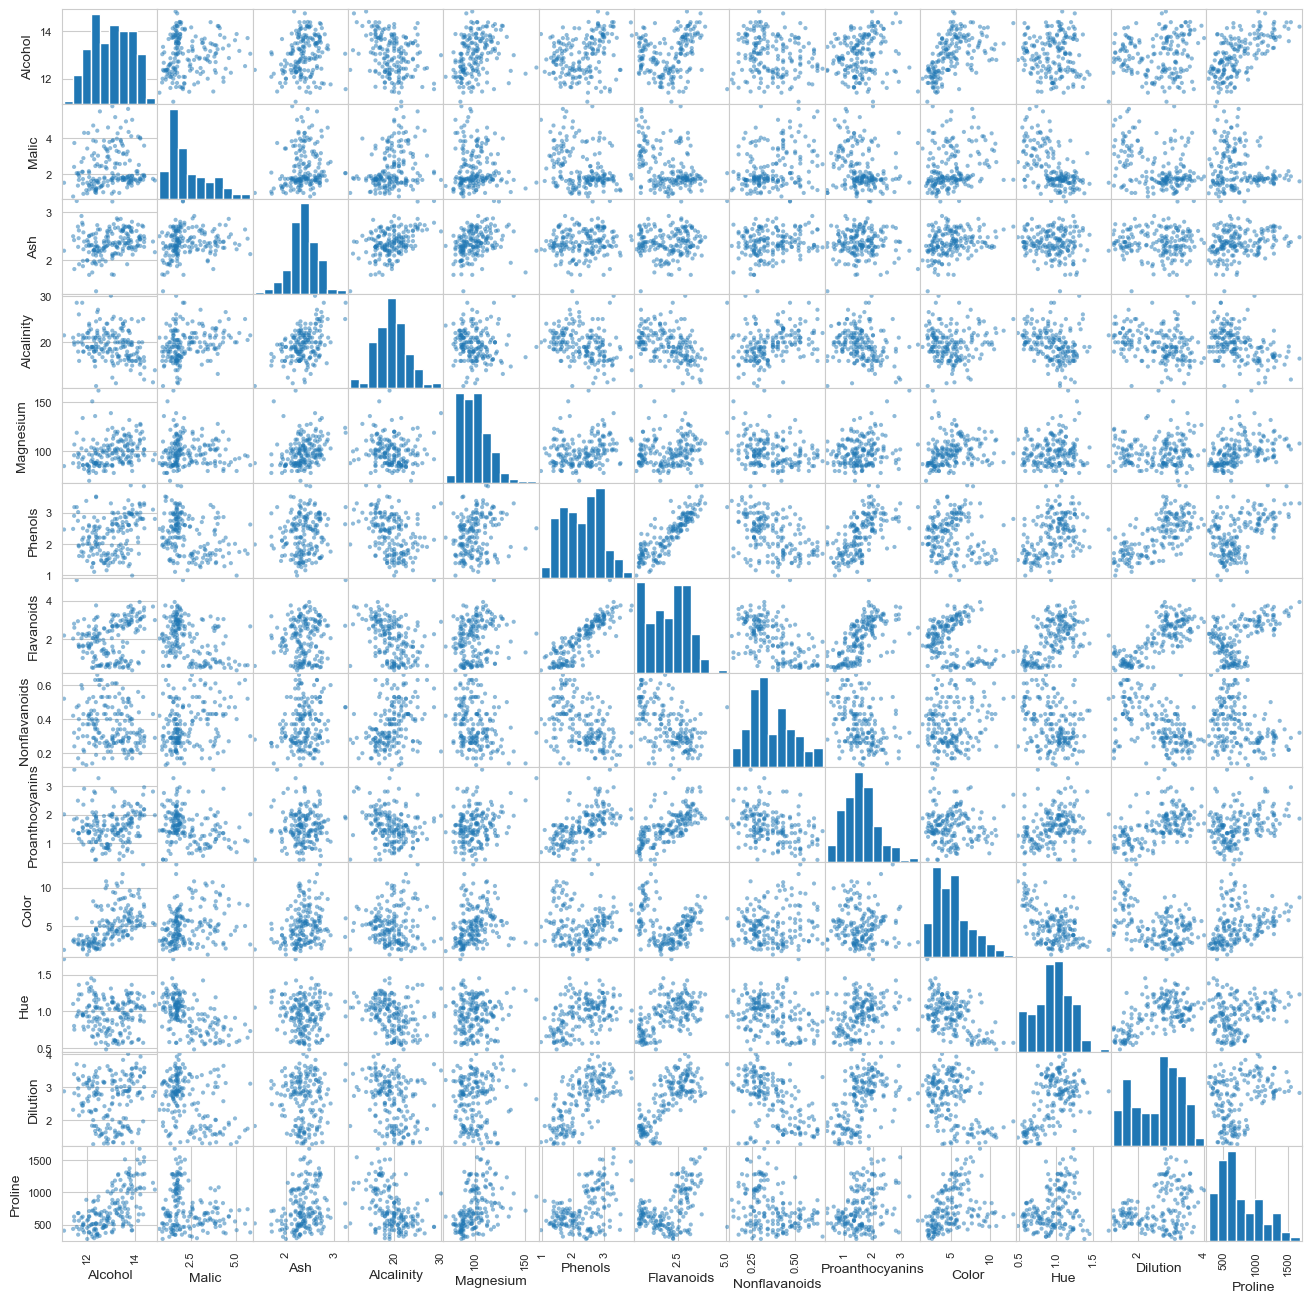

In [17]:
from pandas.plotting import scatter_matrix
scatter_matrix(numeric_cols_df,figsize=(16,16));

#sns.set_style(style='darkgrid')
#sns.pairplot(numeric_cols_df,  kind='reg', plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.1}})

<Axes: >

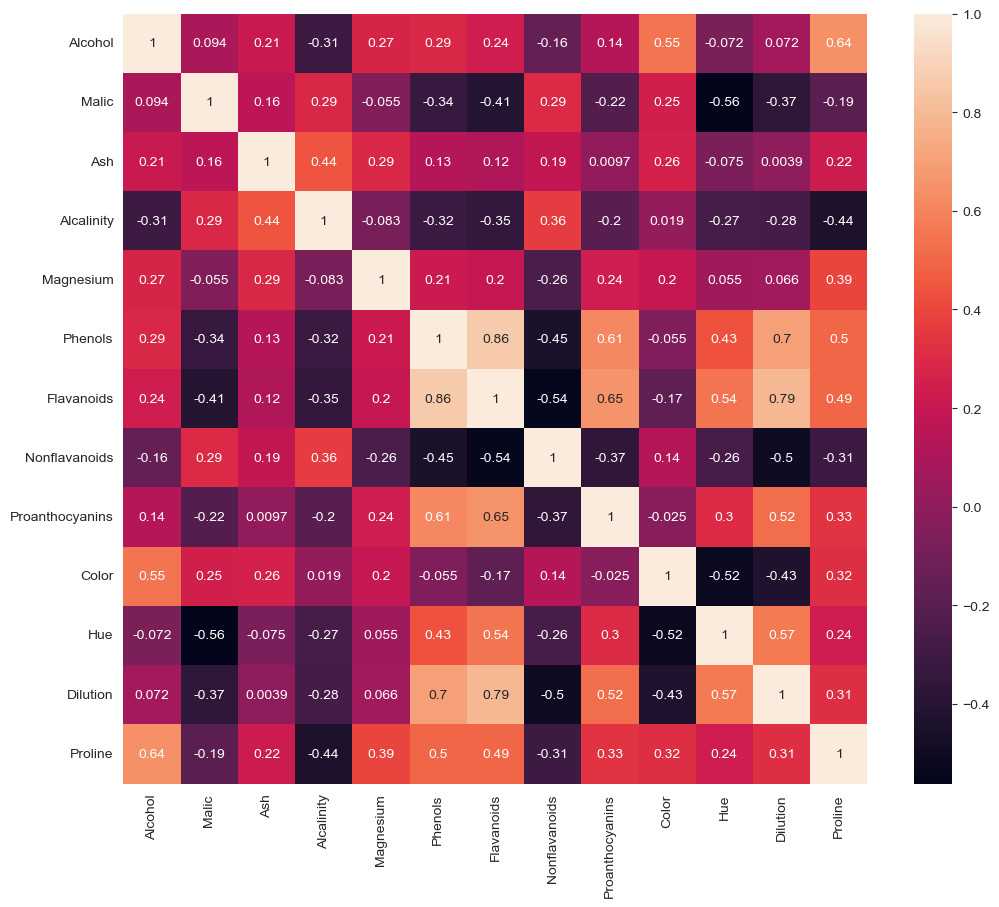

In [18]:
plt.figure(figsize=(12,10))
corrmat=numeric_cols_df.corr()
sns.heatmap(corrmat, annot=True)

**Correlation Analysis Insights**

**Alcohol** shows strong positive correlations with **Proline** (0.64) and **Color** Intensity (0.55), emphasizing its importance in flavor and visual appeal.

**Malic** is nagatively correlated with **Hue** (-0.56).

**Ash** is postively correlated with **Alcalinity** (0.46)

**Phenols** and **Flavanoids** are highly correlated (0.86) and play significant roles in wine structure and complexity.

**Proline** correlates strongly with Alcohol (0.64) and moderately with Phenols (0.50), Alcalinity (-0.44) and Flavanoids (0.49), making it a key indicator of high-quality wines.

Variables like Phenols, Flavanoids, and Alcohol show overlapping relationships, suggesting redundancy that PCA can address

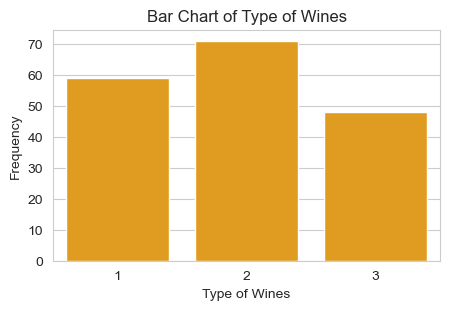

In [19]:
# Assuming 'dataset' is your DataFrame and 'Type' is the column you want to plot
plt.figure(figsize=(5, 3))
sns.countplot(x='Type', data=df, color = 'orange')
plt.title('Bar Chart of Type of Wines')
plt.xlabel('Type of Wines')
plt.ylabel('Frequency')
plt.show()

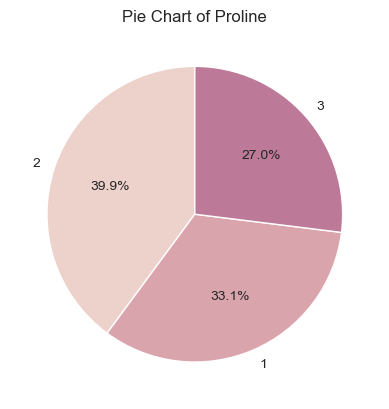

In [20]:
df['Type'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.cubehelix_palette(), startangle=90)
plt.title(f'Pie Chart of {col}')
plt.ylabel('')  # Remove the y-label in case of pie chart
plt.show()

### Task 2: Dimensionality Reduction with PCA:

#### 1. Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.

In [21]:
df_org = df.copy()

In [22]:
df.drop(['Type'], axis = 1, inplace = True)
df.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
standardized_data = scaler.fit_transform(df)
df_std = pd.DataFrame(standardized_data, columns=df.columns)


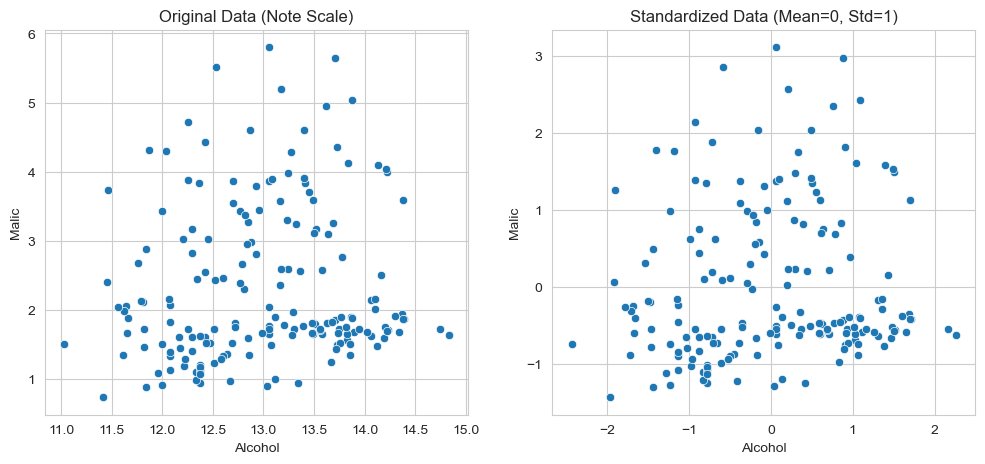

In [25]:
# 3. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Original Data
sns.scatterplot(data=df, x='Alcohol', y='Malic', ax=ax1)
ax1.set_title('Original Data (Note Scale)')

# Standardized Data
sns.scatterplot(data=df_std, x='Alcohol', y='Malic', ax=ax2)
ax2.set_title('Standardized Data (Mean=0, Std=1)')

plt.show()


#### 2. Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.

In [26]:
from sklearn.decomposition import PCA
# Initialize PCA
pca = PCA()
pca_transformed = pca.fit_transform(df_std)


In [27]:
# 3. Calculate Cumulative Explained Variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

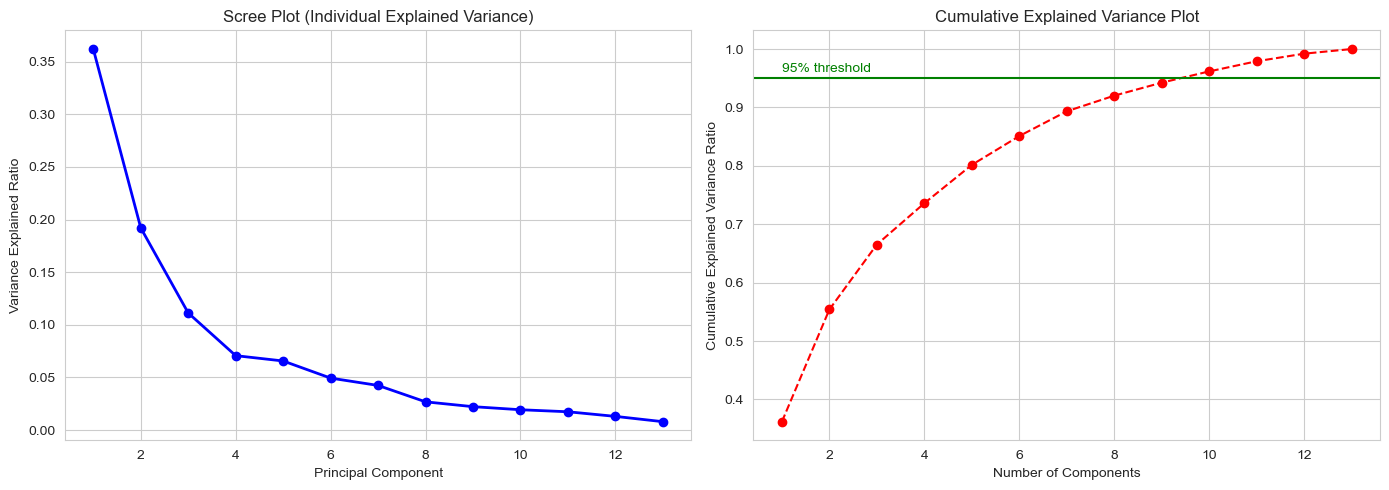

In [28]:
# 4. Create the Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Scree Plot (Individual Variance) ---
ax1.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'o-', linewidth=2, color='blue')
ax1.set_title('Scree Plot (Individual Explained Variance)')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained Ratio')
ax1.grid(True)

# --- Cumulative Explained Variance Plot ---
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='red')
ax2.set_title('Cumulative Explained Variance Plot')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance Ratio')
ax2.axhline(y=0.95, color='green', linestyle='-') # Optional: Draw a line for 95% threshold
ax2.text(1, 0.96, '95% threshold', color='green', fontsize=10)
ax2.grid(True)

plt.tight_layout()
plt.show()


In [29]:
from sklearn.decomposition import PCA

# 5. Determine the number of components for a target variance
# Find the number of components that explain, for example, 95% of the variance
num_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Number of components to explain 95% variance: {num_components_95}")

Number of components to explain 95% variance: 10


#### 3. Transform the original dataset into the principal components.

In [30]:
# 5. Create a new DataFrame with the principal components
pc_columns = [f'PC{i+1}' for i in range(pca_transformed.shape[1])]
principal_df = pd.DataFrame(data=pca_transformed, columns=pc_columns)

print("\nTransformed DataFrame shape:", principal_df.shape)
print("Transformed DataFrame (Principal Components) sample:")
print(principal_df.head())

# Optional: View the explained variance ratio of each component
print("\nExplained variance ratios:")
print(pca.explained_variance_ratio_)


Transformed DataFrame shape: (178, 13)
Transformed DataFrame (Principal Components) sample:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  3.316751  1.443463 -0.165739 -0.215631  0.693043  0.223880  0.596427   
1  2.209465 -0.333393 -2.026457 -0.291358 -0.257655  0.927120  0.053776   
2  2.516740  1.031151  0.982819  0.724902 -0.251033 -0.549276  0.424205   
3  3.757066  2.756372 -0.176192  0.567983 -0.311842 -0.114431 -0.383337   
4  1.008908  0.869831  2.026688 -0.409766  0.298458  0.406520  0.444074   

        PC8       PC9      PC10      PC11      PC12      PC13  
0 -0.065139 -0.641443  1.020956 -0.451563  0.540810 -0.066239  
1 -1.024416  0.308847  0.159701 -0.142657  0.388238  0.003637  
2  0.344216  1.177834  0.113361 -0.286673  0.000584  0.021717  
3 -0.643593 -0.052544  0.239413  0.759584 -0.242020 -0.369484  
4 -0.416700 -0.326819 -0.078366 -0.525945 -0.216664 -0.079364  

Explained variance ratios:
[0.36198848 0.1920749  0.11123631 0.0706903 

### Task 3: Clustering with Original Data:

#### 1. Apply a clustering algorithm (e.g., K-means) to the original dataset.

In [31]:
df.columns

Index(['Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')

In [40]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(df)

# 4. Add the labels back to the original dataframe
df['Cluster'] = cluster_labels

# Display first few rows with cluster labels
print(df.head())

# Optional: View cluster centroids (mean values for each feature)
print(df.groupby('Cluster').mean())

   Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0    14.23   1.71  2.43        15.6        127     2.80        3.06   
1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2    13.16   2.36  2.67        18.6        101     2.80        3.24   
3    14.37   1.95  2.50        16.8        113     3.85        3.49   
4    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  Cluster  
0           0.28             2.29   5.64  1.04      3.92     1065        1  
1           0.26             1.28   4.38  1.05      3.40     1050        1  
2           0.30             2.81   5.68  1.03      3.17     1185        2  
3           0.24             2.18   7.80  0.86      3.45     1480        2  
4           0.39             1.82   4.32  1.04      2.93      735        1  
           Alcohol     Malic       Ash  Alcalinity   Magnesium   Phenols  \
Cluster                            

#### 2. Visualize the clustering results using appropriate plots.

<Axes: xlabel='Alcohol', ylabel='Malic'>

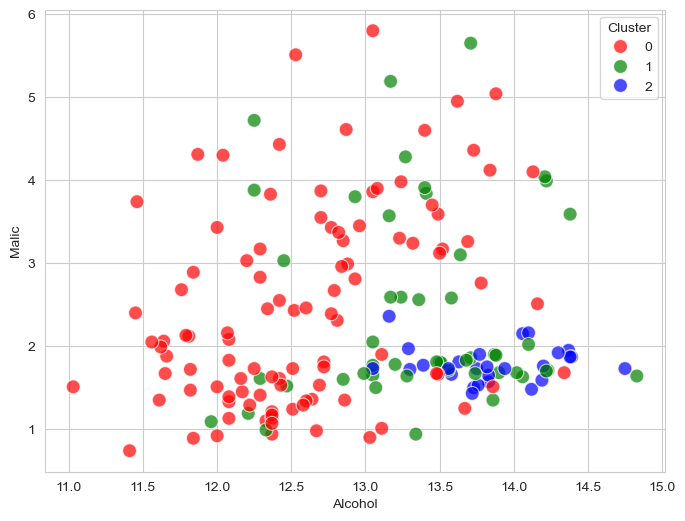

In [41]:
# 6. Visualize the results
plt.figure(figsize=(8, 6))
sns.scatterplot(x="Alcohol", y="Malic", hue="Cluster", data=df, palette=['red', 'green', 'blue'], s=100, alpha=0.7)


#### 3. Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.

In [42]:
df_new = df.copy()
target_name='Cluster'
y= df_new[target_name]#given predictions - training data 
X=df_new.drop(target_name,axis=1)#dropping the Cluster column and keeping 

In [43]:
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

In [44]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
silhouette_avg = silhouette_score(X, y_kmeans)
print(f"Silhouette Score: {silhouette_avg:.3f}")
# A score around 0.74 indicates relatively good separation for this data

# Calculate the Davies-Bouldin Index
# Score is calculated as the average similarity between clusters, where a lower score is better
db_index = davies_bouldin_score(X, y_kmeans)
print(f"Davies-Bouldin Index: {db_index:.3f}")

Silhouette Score: 0.562
Davies-Bouldin Index: 0.544


### Task 4: Clustering with PCA Data:

#### 1. Apply the same clustering algorithm to the PCA-transformed dataset.

In [45]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(principal_df)

# 4. Add the labels back to the original dataframe
principal_df['Cluster'] = cluster_labels

# Display first few rows with cluster labels
print(principal_df.head())

# Optional: View cluster centroids (mean values for each feature)
print(principal_df.groupby('Cluster').mean())



        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  3.316751  1.443463 -0.165739 -0.215631  0.693043  0.223880  0.596427   
1  2.209465 -0.333393 -2.026457 -0.291358 -0.257655  0.927120  0.053776   
2  2.516740  1.031151  0.982819  0.724902 -0.251033 -0.549276  0.424205   
3  3.757066  2.756372 -0.176192  0.567983 -0.311842 -0.114431 -0.383337   
4  1.008908  0.869831  2.026688 -0.409766  0.298458  0.406520  0.444074   

        PC8       PC9      PC10      PC11      PC12      PC13  Cluster  
0 -0.065139 -0.641443  1.020956 -0.451563  0.540810 -0.066239        2  
1 -1.024416  0.308847  0.159701 -0.142657  0.388238  0.003637        2  
2  0.344216  1.177834  0.113361 -0.286673  0.000584  0.021717        2  
3 -0.643593 -0.052544  0.239413  0.759584 -0.242020 -0.369484        2  
4 -0.416700 -0.326819 -0.078366 -0.525945 -0.216664 -0.079364        2  
              PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
Cluster                       

#### 2. Visualize the clustering results obtained from PCA-transformed data.

<Axes: xlabel='PC1', ylabel='PC2'>

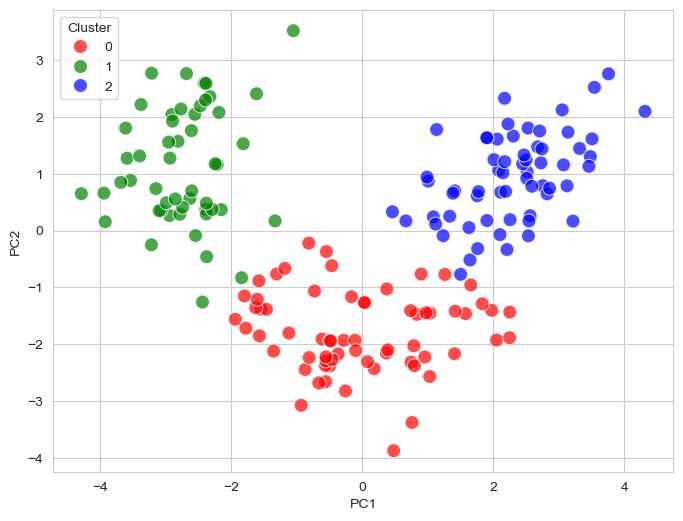

In [46]:
# 6. Visualize the results
plt.figure(figsize=(8, 6))
sns.scatterplot(x="PC1", y="PC2", hue="Cluster", data=principal_df, palette=['red', 'green', 'blue'], s=100, alpha=0.7)


In [47]:
principal_df_new = principal_df.copy()
target_name='Cluster'
y1= principal_df_new[target_name]#given predictions - training data 
X1=principal_df_new.drop(target_name,axis=1)#dropping the Drug Response column and keeping 


In [48]:
kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans.fit(X1)
y1_kmeans = kmeans.predict(X1)


In [49]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
silhouette_avg = silhouette_score(X1, y1_kmeans)
print(f"Silhouette Score: {silhouette_avg:.3f}")
# A score around 0.74 indicates relatively good separation for this data

# Calculate the Davies-Bouldin Index
# Score is calculated as the average similarity between clusters, where a lower score is better
db_index = davies_bouldin_score(X1, y1_kmeans)
print(f"Davies-Bouldin Index: {db_index:.3f}")



Silhouette Score: 0.246
Davies-Bouldin Index: 1.765


#### 3. Compare the clustering results from PCA-transformed data with those from the original dataset.

In [69]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
import matplotlib.pyplot as plt

In [70]:

# Read Data Set
df_main= pd.read_csv('14_wine.csv')
df_main.head() # display 1st 5  observations

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [71]:
df_main_copy = df_main.copy()
target_name='Type'
y_true= df_main_copy[target_name]#given predictions - training data 
X= df_main_copy.drop(target_name,axis=1)#dropping the Drug Response column and keeping 

# Standardize features (PCA is affected by scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply PCA
pca = PCA(n_components=2) # Reduce to 2 components for easy visualization
X_pca = pca.fit_transform(X_scaled)
# Convert to pandas DataFrame for clarity
X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

In [72]:
# 3. Perform K-Means Clustering
kmeans_original = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_original = kmeans_original.fit_predict(X_scaled)

kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca)


In [81]:
# 4. Evaluate and Compare Results

# Metrics for intrinsic evaluation (no true labels needed)
silhouette_original = silhouette_score(X_scaled, clusters_original)
silhouette_pca = silhouette_score(X_pca, clusters_pca)

# Metrics for extrinsic evaluation (requires true labels)
ari_original = adjusted_rand_score(y_true, clusters_original)
ari_pca = adjusted_rand_score(y_true, clusters_pca)

print(f"Comparison of Clustering Results (k=3):")
print(f"----------------------------------------")
print(f"Original Data Silhouette Score: {silhouette_original:.4f}")
print(f"PCA Data Silhouette Score:      {silhouette_pca:.4f}")
print(f"Original Data Adjusted Rand Index: {ari_original:.4f}")
print(f"PCA Data Adjusted Rand Index:      {ari_pca:.4f}")

Comparison of Clustering Results (k=3):
----------------------------------------
Original Data Silhouette Score: 0.2849
PCA Data Silhouette Score:      0.5611
Original Data Adjusted Rand Index: 0.8975
PCA Data Adjusted Rand Index:      0.8951


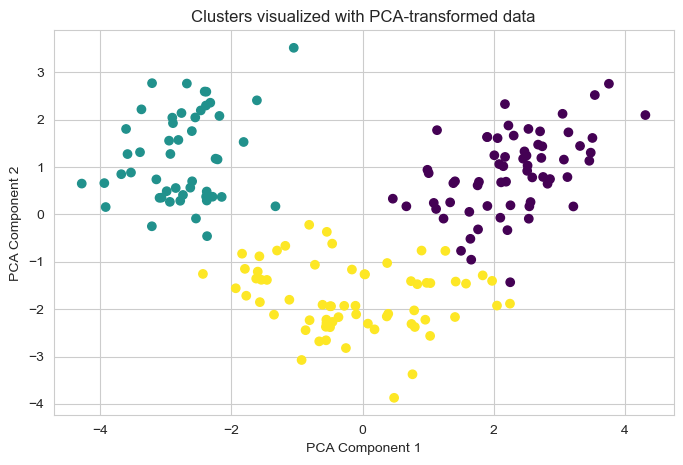

In [82]:
# 5. Visualization (for PCA results)
plt.figure(figsize=(8, 5))
plt.scatter(X_pca_df['PC1'], X_pca_df['PC2'], c=clusters_pca, cmap='viridis')
plt.title("Clusters visualized with PCA-transformed data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


In [83]:
df_main.columns

Index(['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')

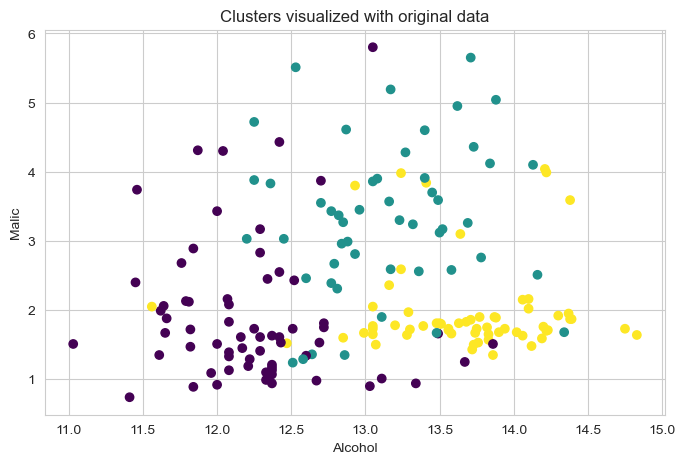

In [84]:
# 5. Visualization (for Original)
plt.figure(figsize=(8, 5))
plt.scatter(X['Alcohol'], X['Malic'], c=clusters_original, cmap='viridis')
plt.title("Clusters visualized with original data")
plt.xlabel("Alcohol")
plt.ylabel("Malic")
plt.show()

### Task 5: Comparison and Analysis:

#### 1. Compare the clustering results obtained from the original dataset and PCA-transformed data.

In [85]:

#  Perform K-Means Clustering (k=3)
k = 3
labels_orig = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
labels_pca = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_pca)

#  Compare Results
print(f"Silhouette (Original): {silhouette_score(X, labels_orig):.3f}")
print(f"Silhouette (PCA): {silhouette_score(X_pca, labels_pca):.3f}")
print(f"ARI (Original): {adjusted_rand_score(y_true, labels_orig):.3f}")
print(f"ARI (PCA): {adjusted_rand_score(y_true, labels_pca):.3f}")

Silhouette (Original): 0.571
Silhouette (PCA): 0.561
ARI (Original): 0.371
ARI (PCA): 0.895


#### 2. Discuss any similarities or differences observed in the clustering results.

**Similarities and Differences in Clustering Results**

**Similarities (Common Findings):**
   * Three Clusters: Clustering algorithms, especially K-Means, successfully identify three primary groups within the wine dataset, corresponding to the three known cultivars.
   * Key Drivers: Alcohol, proline, and color intensity are consistently identified as major factors that differentiate the clusters.
   * Effect of Preprocessing: Without scaling, some features with larger ranges dominate, but after applying StandardScaler, clusters become better defined.


**Differences (Approach & Performance):**
   * PCA Impact: Clustering with Principal Component Analysis (PCA) produces more distinct, compact clusters compared to using raw data, as it reduces multicollinearity (e.g., between flavanoids and total phenols).
   * Algorithm Variability: While K-Means often splits by major, linear differences (alcohol/color), hierarchical clustering (like Ward) may define different boundaries based on hierarchical structure.
   * Feature Importance: Unstandardized data results in features with larger magnitudes (e.g., proline) dominating the cluster assignment.

#### 3. Reflect on the impact of dimensionality reduction on clustering performance.


Dimensionality reduction generally improves clustering performance by mitigating the "curse of dimensionality," where high-dimensional data makes distance metrics less meaningful. Reducing dimensions helps by focusing the clustering algorithm on the most relevant features, reducing noise, and improving computational efficiency and visualization.

**Impact of Dimensionality Reduction on Clustering**

|Impact Area |	Effect	|Rationale|
|-----|----|---|
|Cluster Quality	|Often improves (e.g., better Silhouette Score)	|Removing noisy or irrelevant features helps algorithms like K-Means find more meaningful and distinct clusters.|
|Computational Efficiency	|Significantly faster processing	|Fewer dimensions lead to reduced training and testing time, especially on large datasets.|
|Visualization	|Enables 2D or 3D plotting	|High-dimensional data is impossible to visualize directly; reduction allows for clear visual inspection of the clusters.|
|Overfitting	|Mitigates the risk	|Models are less likely to learn noise in the data, leading to better generalization.|
|Information Loss	|Potential drawback	|Some subtle but meaningful patterns might be lost if the number of components chosen is too small.|


#### 4. Analyze the trade-offs between using PCA and clustering directly on the original dataset.

**Trade-offs: PCA before Clustering vs. Direct Clustering**
    
|Feature |PCA Before Clustering	|Direct Clustering on Original Data|
|---|---|---|
|Dimensionality	|Reduced, focusing on principal components.	High (all original features).
|Computational Efficiency	|Faster training times due to fewer dimensions.	|Can be slow and computationally expensive for large or high-dimensional datasets.|
|Curse of Dimensionality	|Mitigated; distances are more meaningful in reduced space.	|Significant challenge; distance metrics lose effectiveness as dimensions increase.|
|Noise & Redundancy	|Reduced; PCA filters out components with low variance (noise) and handles correlated features.	|Prone to noise and redundant |information (multicollinearity) impacting cluster quality.|
|Interpretability	|Low; principal components are linear combinations of original features and lack original meaning.	|High; clusters are defined directly by the original, understandable features.|
|Information Loss	|Inevitable, as some variance is discarded.	|No information loss from dimensionality reduction, but may still be impacted by noise.|
|Visualization	|Easier to visualize (often reduced to 2D or 3D).	|Difficult or impossible to visualize effectively in high dimensions.|

### Task 6: Conclusion and Insights

#### 1. Summarize the key findings and insights from the assignment.

**Key Findings and Insights**
* **Dimensionality Reduction Efficiency:** The 13 original features (alcohol, malic acid, ash, flavonoids, etc.) were successfully reduced to a few principal components (often 2 or 3) that explain the majority of the variance.
* **Key Drivers of Separation:** PCA indicated that components like Proline, Flavonoids, Total Phenols, and Color Intensity are major contributors to the variance between wine types.
* **Clustering Performance:** When using PCA prior to K-Means clustering, the accuracy and cluster separation improved significantly compared to using all raw features, resulting in better-defined clusters that align with the actual wine cultivars.
* **Need for Standardization:** Due to the varying scales of the chemical measurements (e.g., alcohol vs. proline), normalization (StandardScaler) was essential before applying PCA to ensure that features with larger numerical values did not disproportionately influence the components.
* **Multicollinearity Handling:** PCA helped resolve high correlations between variables (e.g., Total Phenols and Flavanoids), allowing for a more efficient model with non-redundant components.

#### 2. Discuss the practical implications of using PCA and clustering in data analysis.

**Practical Implications**
* **Improved Performance and Speed:** PCA reduces the number of variables, which significantly cuts down the computational cost and training time for clustering algorithms, making analysis of large datasets more efficient.
* **Mitigating the Curse of Dimensionality:** High-dimensional data can make distance calculations less meaningful in clustering. PCA projects the data into a lower-dimensional space where distances (like Euclidean distance used in K-means) are more reliable, leading to more distinct and meaningful clusters.
* **Noise Reduction:** Principal components with low variance often correspond to noise or less significant information. By selecting only the top components that capture most of the data's variance, noise is inherently reduced, which can improve the quality of the clustering results.
* **Enhanced Visualization:** It is difficult to visualize data with many features. PCA allows the projection of data into two or three dimensions (the first two or three principal components), enabling analysts to visually inspect the data and the resulting clusters in scatter plots.
* **Addressing Multicollinearity:** PCA transforms original correlated features into new, uncorrelated (orthogonal) principal components, which can eliminate issues related to multicollinearity that might otherwise distort clustering results.
* **Easier Interpretation of Clusters:** The combined approach allows visualization of clusters in the 2D or 3D PCA space. Analysts can then examine the characteristics of the original variables that contribute most to each principal component (the loadings) to interpret the nature of each cluster.

#### 3. Provide recommendations for when to use each technique based on the analysis conducted.

**Recommendations for When to Use PCA**

**Use PCA when:**
* Dimensionality Reduction is needed: You have a large number of features, and you want to reduce the feature space while retaining the maximum amount of variance (information).
* Multicollinearity exists: Your independent variables are highly correlated. PCA creates new, uncorrelated variables (principal components), which can resolve this issue in regression analysis.
* Visualization is difficult: You cannot easily visualize data with many dimensions. PCA can project data into a 2D or 3D space, making patterns more interpretable.
* Computational efficiency is a concern: Reducing the number of features leads to faster training times for machine learning algorithms.
* Noise Reduction is desired: Components with low variance, often corresponding to noise, can be removed from the analysis